In [ ]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path_to_data_folder = "/content/drive/MyDrive/DSCI 303/"

import os
os.chdir(path_to_data_folder)

df = pd.read_csv('college_students_habits_1M.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Info + summary
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 42 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   study_hours               1000000 non-null  float64
 1   attendance                1000000 non-null  float64
 2   assignment_completion     1000000 non-null  float64
 3   midterm_score             1000000 non-null  float64
 4   final_score               1000000 non-null  float64
 5   project_score             1000000 non-null  float64
 6   backlogs                  1000000 non-null  int64  
 7   sleep_hours               1000000 non-null  float64
 8   stress                    1000000 non-null  float64
 9   anxiety                   1000000 non-null  float64
 10  depression                1000000 non-null  float64
 11  motivation                1000000 non-null  float64
 12  concentration             1000000 non-null  float64
 13  time_management           10

,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,relationship_status,hostel_student,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress,gpa
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,4.042036,74.876365,69.896701,60.011309,64.856105,67.972723,2.550791,6.499550,3.211822,49.986145,...,0.309228,0.499858,2.999902,60.068814,6.001131,5.008589,3.002335,2.511193,4.998476,0.831196
std,2.212739,12.892864,14.682793,14.967273,17.606373,13.877038,1.650993,0.435650,1.756919,14.999785,...,0.462176,0.500000,0.998515,19.884181,1.496727,1.713582,1.000212,1.415504,1.340340,0.295290
min,0.000000,30.000000,20.000000,0.000000,0.000000,0.000000,0.000000,4.520054,1.000000,0.000000,...,0.000000,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,2.457050,66.092450,59.909055,49.891078,52.869294,58.565006,1.000000,6.206206,1.686328,39.862051,...,0.000000,0.000000,2.324179,46.560403,4.989108,3.834943,2.326072,1.326072,4.090790,0.626618
50%,4.004593,75.027325,70.021207,60.027573,65.033085,68.025735,2.000000,6.498872,3.046761,49.973913,...,0.000000,0.000000,2.999001,60.019001,6.002757,5.003885,3.001838,3.001838,4.996261,0.830458
75%,5.552457,83.971757,80.136895,70.158226,77.189865,77.481010,4.000000,6.793280,4.410195,60.099820,...,1.000000,1.000000,3.675471,73.526887,7.015822,6.173169,3.677215,3.677215,5.903410,1.034218
max,12.000000,100.000000,100.000000,100.000000,100.000000,100.000000,10.000000,8.763114,10.000000,100.000000,...,1.000000,1.000000,7.531504,154.914220,10.000000,10.000000,8.062667,8.062667,10.000000,2.009058


In [ ]:
# Missing ratio per column
df_na = df.isnull().mean().sort_values(ascending=False)
print(df_na.head(10))

performance_level        0.001558
study_hours              0.000000
assignment_completion    0.000000
midterm_score            0.000000
final_score              0.000000
project_score            0.000000
backlogs                 0.000000
sleep_hours              0.000000
stress                   0.000000
attendance               0.000000
dtype: float64


In [ ]:
# Total missing
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 1558


In [ ]:
# Numerical --> median
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical --> mode
for col in df.select_dtypes(exclude='number').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Check again
print("Remaining missing:", df.isnull().sum().sum())

Remaining missing: 0


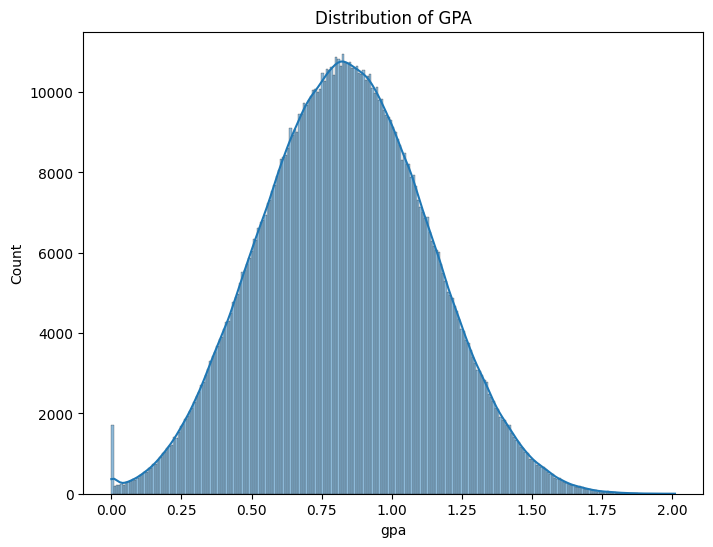

In [ ]:
# Target variable distribution (GPA)
plt.figure(figsize=(8,6))
sns.histplot(df['gpa'], kde=True)
plt.title('Distribution of GPA')
plt.show()

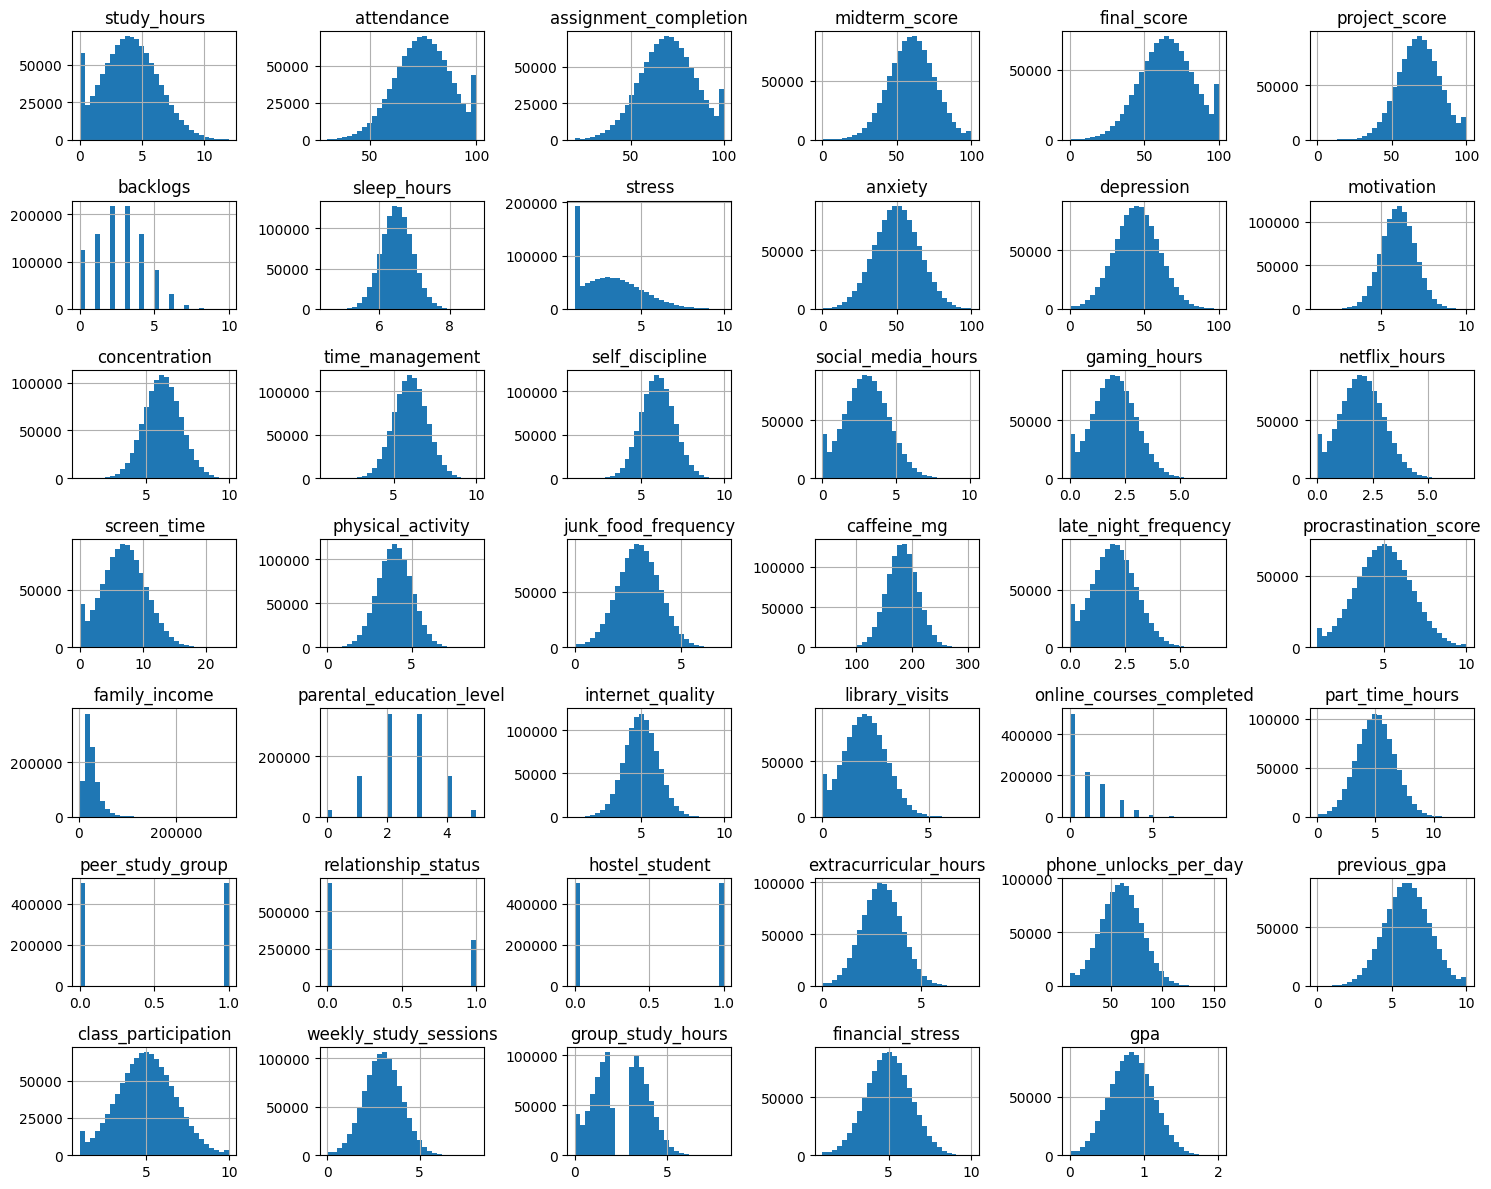

In [ ]:
# Numerical feature distribution

df_num = df.select_dtypes(include='number')

df_num.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

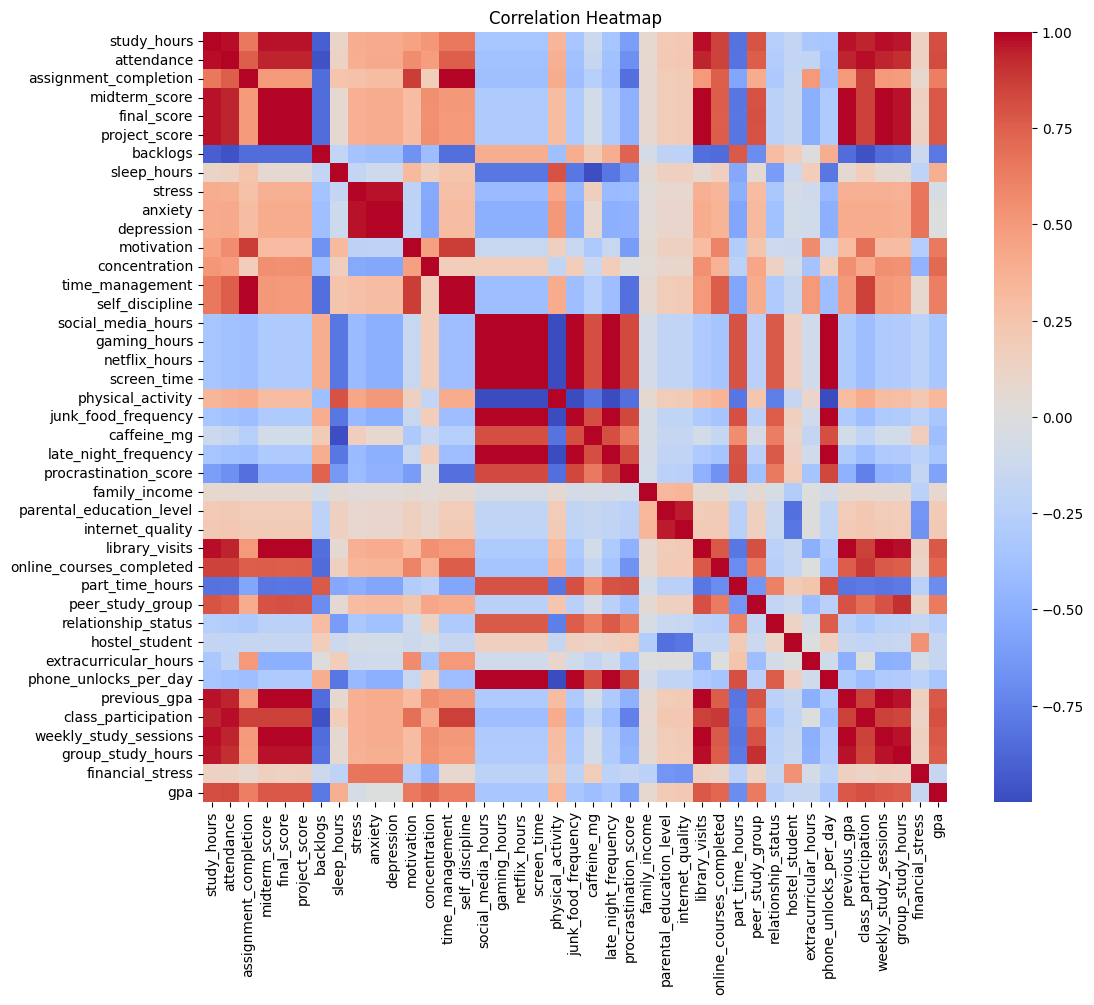

In [ ]:
# Correlation analysis (heatmap)

corr = df_num.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Top features correlated w/ GPA

corr_target = corr['gpa'].abs().sort_values(ascending=False)

top_features = corr_target.drop('gpa').head(5).index.tolist()
print("Top features:", top_features)

Top features: ['attendance', 'study_hours', 'class_participation', 'backlogs', 'library_visits']


In [ ]:
# Example of feature engineering

# Example: combine behavior features if applicable
if all(col in df.columns for col in ['study_hours', 'sleep_hours']):
    df['study_sleep_ratio'] = df['study_hours'] / (df['sleep_hours'] + 1)

In [ ]:
# Encoding categorical var

df = pd.get_dummies(df, drop_first=True)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7849e7284540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1146, in _make_controller_from_path
    filepath = _realpath(filepath)
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 548, in _realpath
    return os.path.realpath(filepath)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen posixpath>", line 425, in realpath
  File "<frozen posixpath>", line 412, in abspath
OSError: [Errno 107] Transport endpoint is not connected


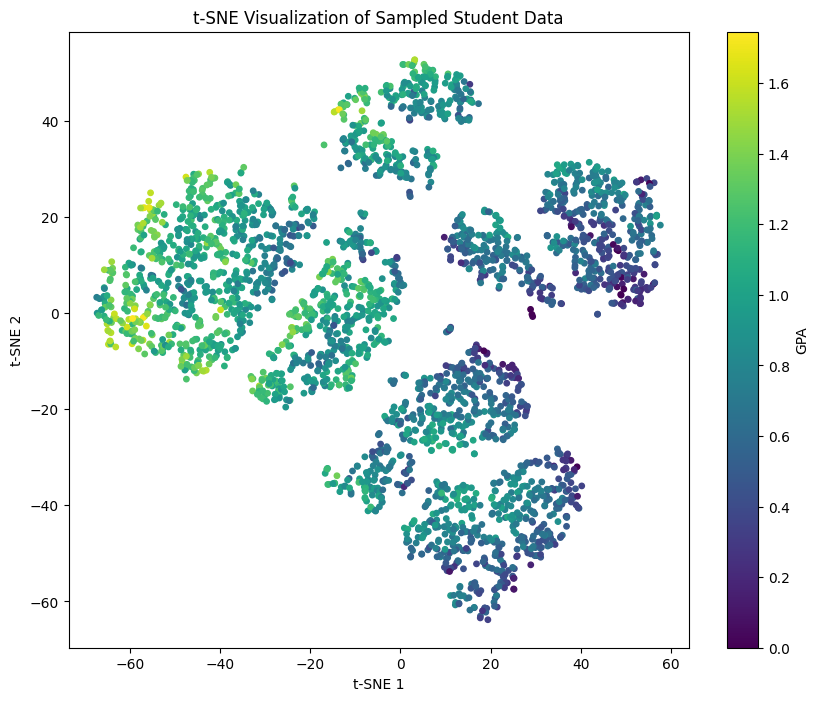

In [ ]:
# t-SNE on random sample (cannot run on 1M rows)

# Separate target
y = df['gpa']
X = df.drop('gpa', axis=1)

# One-hot encode if needed
X = pd.get_dummies(X, drop_first=True)

# Sample a smaller subset for t-SNE
sample_size = 3000
sample_idx = np.random.choice(X.index, sample_size, replace=False)

X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]

# Scale
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_sample_scaled)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_sample, cmap='viridis', s=15)
plt.colorbar(label='GPA')
plt.title('t-SNE Visualization of Sampled Student Data')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

In [ ]:
# Baseline models

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline 1 (mean)

y_train_pred = np.full(len(y_train), y_train.mean())
y_test_pred = np.full(len(y_test), y_train.mean())

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Mean Baseline Train RMSE:", rmse_train)
print("Mean Baseline Test RMSE:", rmse_test)

# Baseline 2 (lin reg)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("LR Train RMSE:", rmse_train)
print("LR Test RMSE:", rmse_test)

print("LR Test MAE:", mean_absolute_error(y_test, y_test_pred))
print("LR Test R2:", r2_score(y_test, y_test_pred))

Mean Baseline Train RMSE: 0.2951673124089
Mean Baseline Test RMSE: 0.29578006236306714
LR Train RMSE: 0.10081846557053362
LR Test RMSE: 0.10071761759707654
LR Test MAE: 0.0802862285439428
LR Test R2: 0.8840491093299915


In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline 1 (mean)

y_train_pred_mean = np.full(len(y_train), y_train.mean())
y_test_pred_mean = np.full(len(y_test), y_train.mean())

rmse_train_mean = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))

mae_test_mean = mean_absolute_error(y_test, y_test_pred_mean)
r2_test_mean = r2_score(y_test, y_test_pred_mean)

print("Mean Baseline Train RMSE:", rmse_train_mean)
print("Mean Baseline Test RMSE:", rmse_test_mean)
print("Mean Baseline Test MAE:", mae_test_mean)
print("Mean Baseline Test R2:", r2_test_mean)

# Baseline 2 (lin reg)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

print("\nLinear Regression Train RMSE:", rmse_train_lr)
print("Linear Regression Test RMSE:", rmse_test_lr)
print("Linear Regression Test MAE:", mae_test_lr)
print("Linear Regression Test R2:", r2_test_lr)

Mean Baseline Train RMSE: 0.2951673124089
Mean Baseline Test RMSE: 0.29578006236306714
Mean Baseline Test MAE: 0.23809165278263597
Mean Baseline Test R2: -2.285888116126955e-06

Linear Regression Train RMSE: 0.10081846557053362
Linear Regression Test RMSE: 0.10071761759707654
Linear Regression Test MAE: 0.0802862285439428
Linear Regression Test R2: 0.8840491093299915


# Clustering

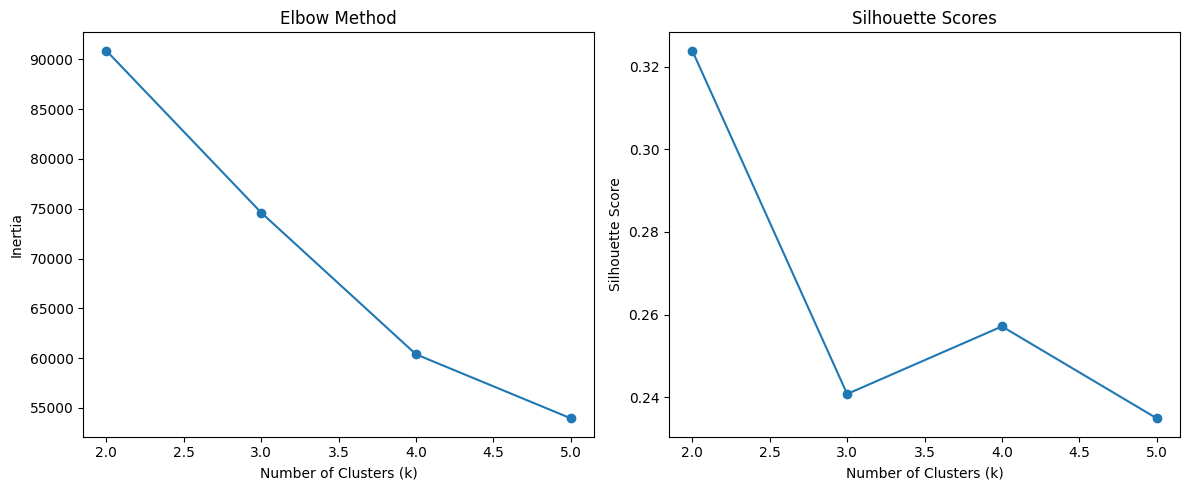

Final silhouette score: 0.2408294494449761
Cluster sizes:
cluster
0    2815
1    2636
2    4549
Name: count, dtype: int64

Cluster means:
         study_hours  attendance  sleep_hours  social_media_hours  \
cluster                                                             
0               6.36       88.76         6.78                1.69   
1               2.09       62.40         6.13                4.63   
2               3.81       73.87         6.54                2.90   

         netflix_hours  screen_time  physical_activity  class_participation  \
cluster                                                                       
0                 1.13         3.94               4.90                 6.91   
1                 3.09        10.81               2.91                 3.30   
2                 1.94         6.78               4.06                 4.86   

         weekly_study_sessions  library_visits  phone_unlocks_per_day  \
cluster                                        

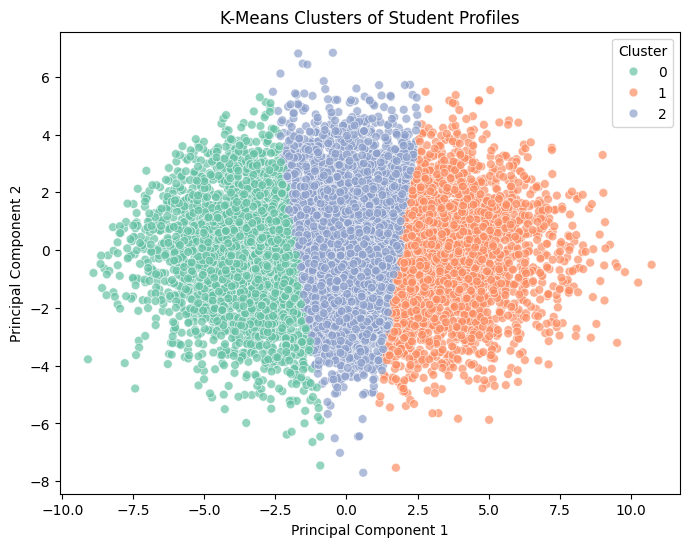

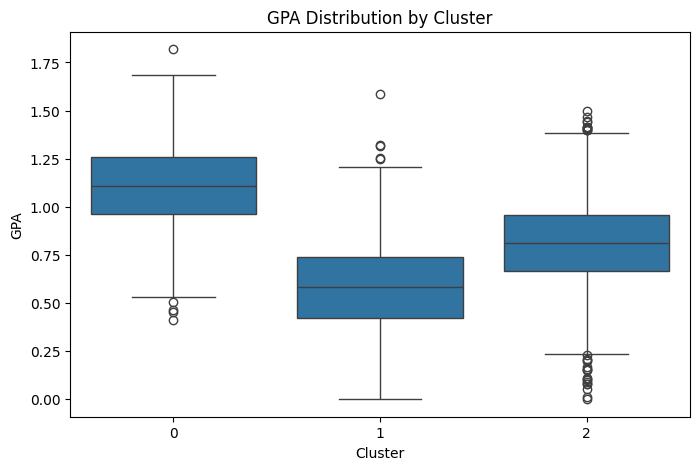

In [ ]:
# Clustering

cluster_features = [
    'study_hours',
    'attendance',
    'sleep_hours',
    'social_media_hours',
    'netflix_hours',
    'screen_time',
    'physical_activity',
    'class_participation',
    'weekly_study_sessions',
    'library_visits',
    'phone_unlocks_per_day',
    'time_management',
    'self_discipline',
    'motivation',
    'procrastination_score'
]

cluster_df = df[cluster_features + ['gpa']].dropna().copy()

sample_n = 10000
if len(cluster_df) > sample_n:
    cluster_df = cluster_df.sample(n=sample_n, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

inertias = []
sil_scores = []
k_values = range(2, 6)  # smaller range = faster

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.subplot(1, 2, 2)
plt.plot(list(k_values), sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")

plt.tight_layout()
plt.show()

best_k = 3

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Final silhouette score:", silhouette_score(X_scaled, cluster_df['cluster']))

cluster_summary = cluster_df.groupby('cluster')[cluster_features + ['gpa']].mean().round(2)
cluster_counts = cluster_df['cluster'].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_counts)
print("\nCluster means:")
print(cluster_summary)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df['PC1'] = X_pca[:, 0]
cluster_df['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cluster_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    alpha=0.7,
    s=40
)
plt.title("K-Means Clusters of Student Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=cluster_df, x='cluster', y='gpa')
plt.title("GPA Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("GPA")
plt.show()

In [ ]:
# ANOVA for GPA differences across K-Means clusters

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

anova_df = cluster_df[['cluster', 'gpa']].dropna().copy()
groups = [
    anova_df.loc[anova_df['cluster'] == k, 'gpa']
    for k in sorted(anova_df['cluster'].unique())
]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("ANOVA p-value:", p_value)

grand_mean = anova_df['gpa'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = sum((anova_df['gpa'] - grand_mean) ** 2)
eta_squared = ss_between / ss_total

print("Eta squared:", eta_squared)

tukey = pairwise_tukeyhsd(
    endog=anova_df['gpa'],
    groups=anova_df['cluster'],
    alpha=0.05
)

print(tukey)

ANOVA F-statistic: 3897.7662001184713
ANOVA p-value: 0.0
Eta squared: 0.4381350684028055
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     0      1  -0.5277   0.0 -0.5418 -0.5136   True
     0      2  -0.2972   0.0 -0.3097 -0.2847   True
     1      2   0.2305   0.0  0.2178  0.2432   True
---------------------------------------------------


# Neural Network

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0242 - val_loss: 0.0110
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0108 - val_loss: 0.0112
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0106 - val_loss: 0.0118
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0104 - val_loss: 0.0112
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Neural Network RMSE: 0.1048040437294257


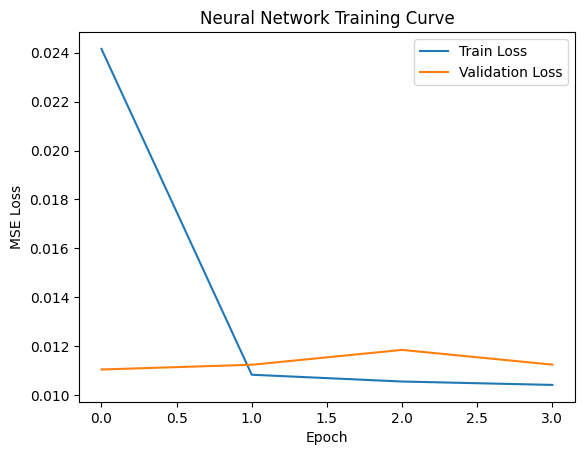

In [ ]:
# Neural network model

X = df.drop('gpa', axis=1)
y = df['gpa']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # output layer (regression)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(X_test_scaled)

rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred))
print("Neural Network RMSE:", rmse_nn)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Neural Network Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [ ]:
y_train_pred_nn = model.predict(X_train_scaled).flatten()

rmse_train_nn = np.sqrt(mean_squared_error(y_train, y_train_pred_nn))

y_test_pred_nn = model.predict(X_test_scaled).flatten()

rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_test_pred_nn))

print("Neural Network Train RMSE:", rmse_train_nn)
print("Neural Network Test RMSE:", rmse_test_nn)

25000/25000 ━━━━━━━━━━━━━━━━━━━━ 31s 1ms/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Neural Network Train RMSE: 0.10485444798808466
Neural Network Test RMSE: 0.1048040437294257


# Random Forest

In [ ]:
!pip install mglearn

import mglearn

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spi

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_15029/2553280898.py", line 3, in <cell line: 0>
    import mglearn
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1322, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 1262, in _find_spec
  File "<frozen importlib._bootstrap_external>", line 1532, in find_spec
  File "<frozen importlib._bootstrap_external>", line 1504, in _get_spec
  File "<frozen importlib._bootstrap_external>", line 1483, in _path_importer_cache
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback


In [ ]:

forest = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

forest.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_train_pred_rf = forest.predict(X_train)
y_test_pred_rf = forest.predict(X_test)

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Train RMSE:", rmse_train_rf)
print("Random Forest Test RMSE:", rmse_test_rf)
print("Random Forest Test MAE:", mae_test_rf)
print("Random Forest Test R2:", r2_test_rf)

In [ ]:
def plot_feature_importances_df(model):
    n_features = X.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_df(forest)

# SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

X_sample = X_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(forest)
shap_values = explainer.shap_values(X_sample)

In [ ]:
shap.summary_plot(shap_values, X_sample, max_display=10)

In [ ]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [ ]:
shap.dependence_plot("study_hours", shap_values, X_sample)

# LLM

In [ ]:
import os
os.chdir('/content')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
# Install Google Gen AI SDK for Python
%pip install --upgrade --quiet google-genai gitingest

In [ ]:
# Authenticate notebook environment
import sys

# Additional authentication is required for Google Colab
if "google.colab" in sys.modules:
    # Authenticate user to Google Cloud
    from google.colab import auth

    auth.authenticate_user()

In [ ]:
# Set Google Cloud project information and create client
import os

from google import genai

# fmt: off
PROJECT_ID = "dsci303-test"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}

# fmt: on
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "global")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

In [ ]:
import nest_asyncio
from IPython.display import Audio, Image, Markdown, Video, display
from gitingest import ingest
from google.genai.types import CreateCachedContentConfig, GenerateContentConfig, Part

nest_asyncio.apply()

In [ ]:
# Load gemini 2.5 flash model
MODEL_ID = "gemini-2.5-flash"  # @param {type: "string"}

In [ ]:
model_insights = """
- Attendance is the strongest predictor of GPA; higher attendance strongly increases GPA
- Concentration and class participation are also strong positive predictors
- Procrastination negatively impacts GPA
- Sleep has a small positive effect
- Social media and screen time have little to no impact
"""

prompt = f"""
You are analyzing results from a machine learning model predicting student GPA.

Here are the key findings:
{model_insights}

Based on these findings:
1. Generate 5 clear, actionable recommendations for college students
2. Each recommendation should include specific guidance (e.g., hours, frequency)
3. Keep it practical and realistic
4. Do not introduce new factors not listed above

Format:
- Bullet points
- One sentence explanation per recommendation

Based on the findings, generate 5 actionable recommendations for college students.
Each recommendation should include specific, measurable units (like hours or frequency)
Do not introduce new factors.
Explain your reasoning for each recommendation.

"""

config = GenerateContentConfig(
    temperature=1.0 # randomness in the model output. 0= fully deterministic. higher values (0.5-1.0) will make more creative and varied response
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=config
)

print("\nGemini Response:\n")
print(response.text)